In [1]:
!pip install -q sentence-transformers

In [2]:
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util
import os
from google.colab import drive

In [3]:
torch.cuda.empty_cache()

In [4]:
# 1. Setup & Load Data
drive.mount('/content/drive')
baseline_path = '/content/drive/MyDrive/Project/results/baseline_results.csv'
perturbed_path = '/content/drive/MyDrive/Project/results/perturbed_results.csv'

df_base = pd.read_csv(baseline_path)
df_pert = pd.read_csv(perturbed_path)

# Ensure we are comparing the same samples by merging on the original index
df_merged = pd.merge(
    df_base[['index', 'cwe', 'baseline_explanation']], 
    df_pert[['index', 'perturbed_explanation']], 
    on='index'
)

# 2. Load SBERT Model 'all-MiniLM-L6-v2'
model = SentenceTransformer('all-MiniLM-L6-v2')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
def calculate_metrics(row):
    # Encode both explanations into vectors (embeddings)
    emb1 = model.encode(row['baseline_explanation'], convert_to_tensor=True)
    emb2 = model.encode(row['perturbed_explanation'], convert_to_tensor=True)
    
    # Calculate Cosine Similarity
    cosine_sim = util.pytorch_cos_sim(emb1, emb2).item()
    
    # Calculate Semantic Variance
    semantic_variance = 1 - cosine_sim
    
    return pd.Series([cosine_sim, semantic_variance])

In [6]:
# 3. Execute Analysis
print(f"--- Analyzing Semantic Variance for {len(df_merged)} samples ---")
df_merged[['cosine_similarity', 'semantic_variance']] = df_merged.apply(calculate_metrics, axis=1)

# 4. Save Final Analysis
output_path = '/content/drive/MyDrive/Project/results/rq1_final_analysis.csv'
df_merged.to_csv(output_path, index=False)

# 5. Summary Statistics
print("\n--- RQ1 Global Statistics ---")
print(f"Mean Cosine Similarity: {df_merged['cosine_similarity'].mean():.4f}")
print(f"Mean Semantic Variance: {df_merged['semantic_variance'].mean():.4f}")
print(f"Max Variance (Most Unstable): {df_merged['semantic_variance'].max():.4f}")

--- Analyzing Semantic Variance for 64 samples ---

--- RQ1 Global Statistics ---
Mean Cosine Similarity: 0.4589
Mean Semantic Variance: 0.5411
Max Variance (Most Unstable): 0.9555


In [7]:
# Analysis A: Stability Categorization
def categorize_stability(variance):
    if variance < 0.15: return 'High Stability'
    elif variance < 0.40: return 'Moderate Stability'
    else: return 'Unstable/Volatile'

df_merged['stability_category'] = df_merged['semantic_variance'].apply(categorize_stability)

print("\n--- Analysis A: Stability Distribution ---")
print(df_merged['stability_category'].value_counts(normalize=True) * 100)


--- Analysis A: Stability Distribution ---
stability_category
Unstable/Volatile     96.875
Moderate Stability     3.125
Name: proportion, dtype: float64


In [8]:
# Analysis B: CWE Sensitivity
# We calculate the mean variance for each CWE category
cwe_analysis = df_merged.groupby('cwe')['semantic_variance'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

print("\n--- Analysis B: CWE Sensitivity (Top 5 Most Unstable) ---")
print(cwe_analysis.head(5))

# Save this specific table for your report
cwe_analysis.to_csv('/content/drive/MyDrive/Project/results/cwe_sensitivity_stats.csv')


--- Analysis B: CWE Sensitivity (Top 5 Most Unstable) ---
             mean  count
cwe                     
CWE-20   0.616079      9
CWE-399  0.606571      5
CWE-59   0.605992      1
CWE-200  0.585378      1
CWE-254  0.567306      1


In [9]:
# Analysis C: Identify samples for manual qualitative review
failure_cases = df_merged.sort_values(by='semantic_variance', ascending=False).head(5)

for i, row in failure_cases.iterrows():
    print(f"\n--- FAILURE CASE: Index {row['index']} (CWE: {row['cwe']}) ---")
    print(f"VARIANCE SCORE: {row['semantic_variance']:.4f}")
    print(f"BASELINE: {row['baseline_explanation'][:200]}...")
    print(f"PERTURBED: {row['perturbed_explanation'][:200]}...")


--- FAILURE CASE: Index 4 (CWE: CWE-20) ---
VARIANCE SCORE: 0.9555
BASELINE: The issue here is that the code is creating a new view object (LayoutPropagationView) and then immediately setting its layout manager, border, and background. However, it's not setting the layout mana...
PERTURBED: The code is vulnerable to a buffer overflow because it does not check the return value of the function calls. This can lead to unpredictable behavior and potentially allow an attacker to execute arbit...

--- FAILURE CASE: Index 112 (CWE: CWE-264) ---
VARIANCE SCORE: 0.7476
BASELINE: The problem lies in the Observe function call. It is called with a raw pointer to web_contents_ instead of the unique_ptr. This can lead to undefined behavior because the unique_ptr's ownership semant...
PERTURBED: The code is vulnerable to a variety of issues, including memory leaks, buffer overflows, and potential crashes. Here's why:

1. The code is using a constructor to initialize two member variables, `var...

--

Data preview:


,cwe,mean,count
0,CWE-20,0.616079,9
1,CWE-399,0.606571,5
2,CWE-59,0.605992,1
3,CWE-200,0.585378,1
4,CWE-254,0.567306,1
5,CWE-362,0.561014,4
6,CWE-285,0.552250,1
7,CWE-125,0.547669,5
8,CWE-189,0.545005,3
9,CWE-732,0.532806,1


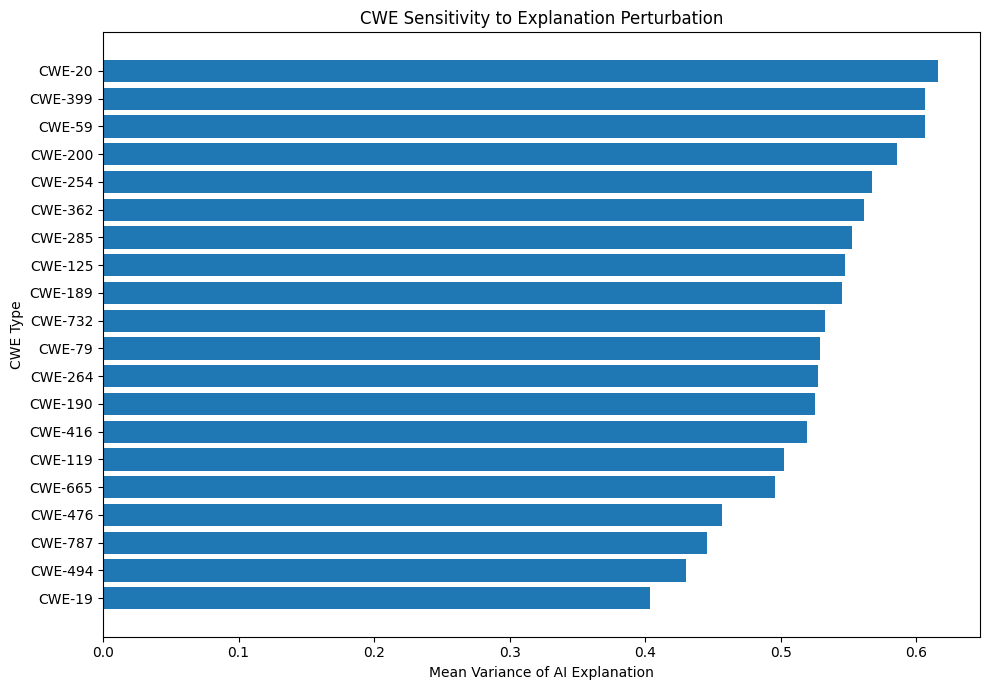

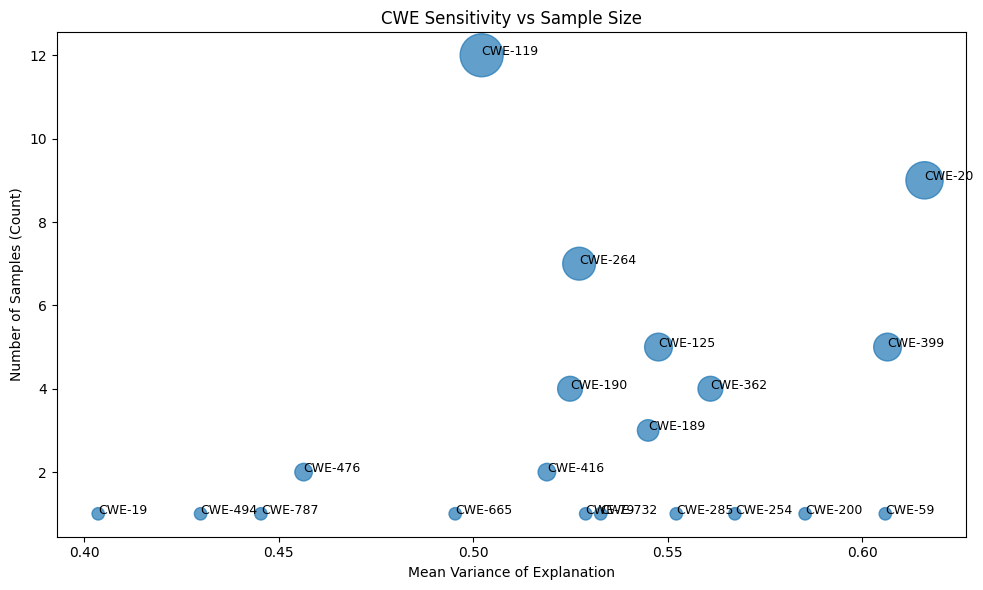

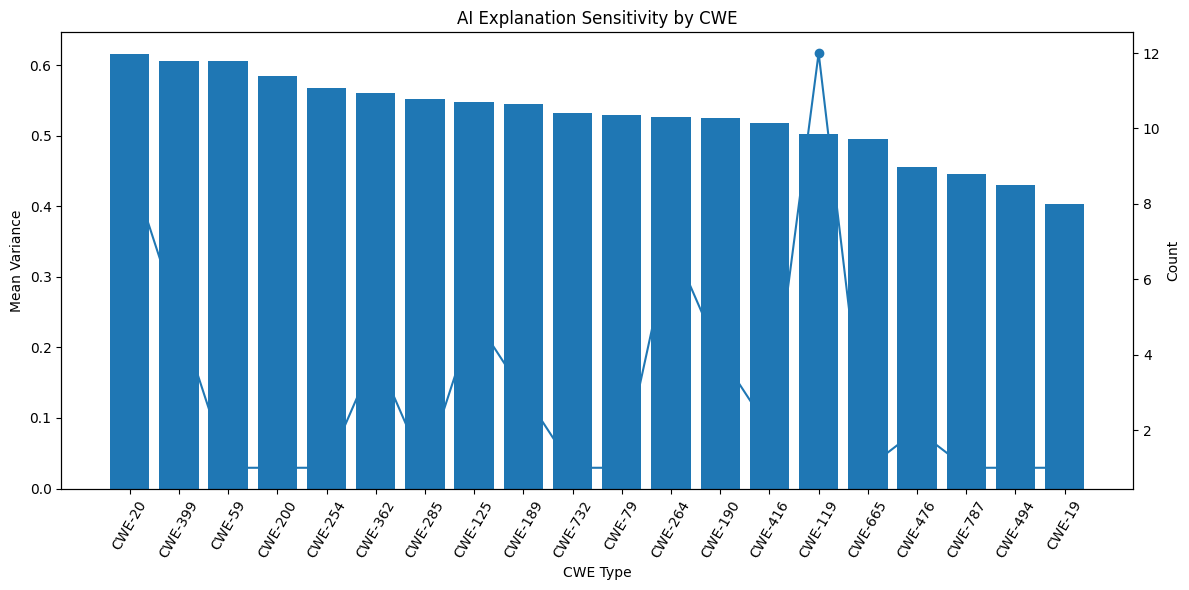

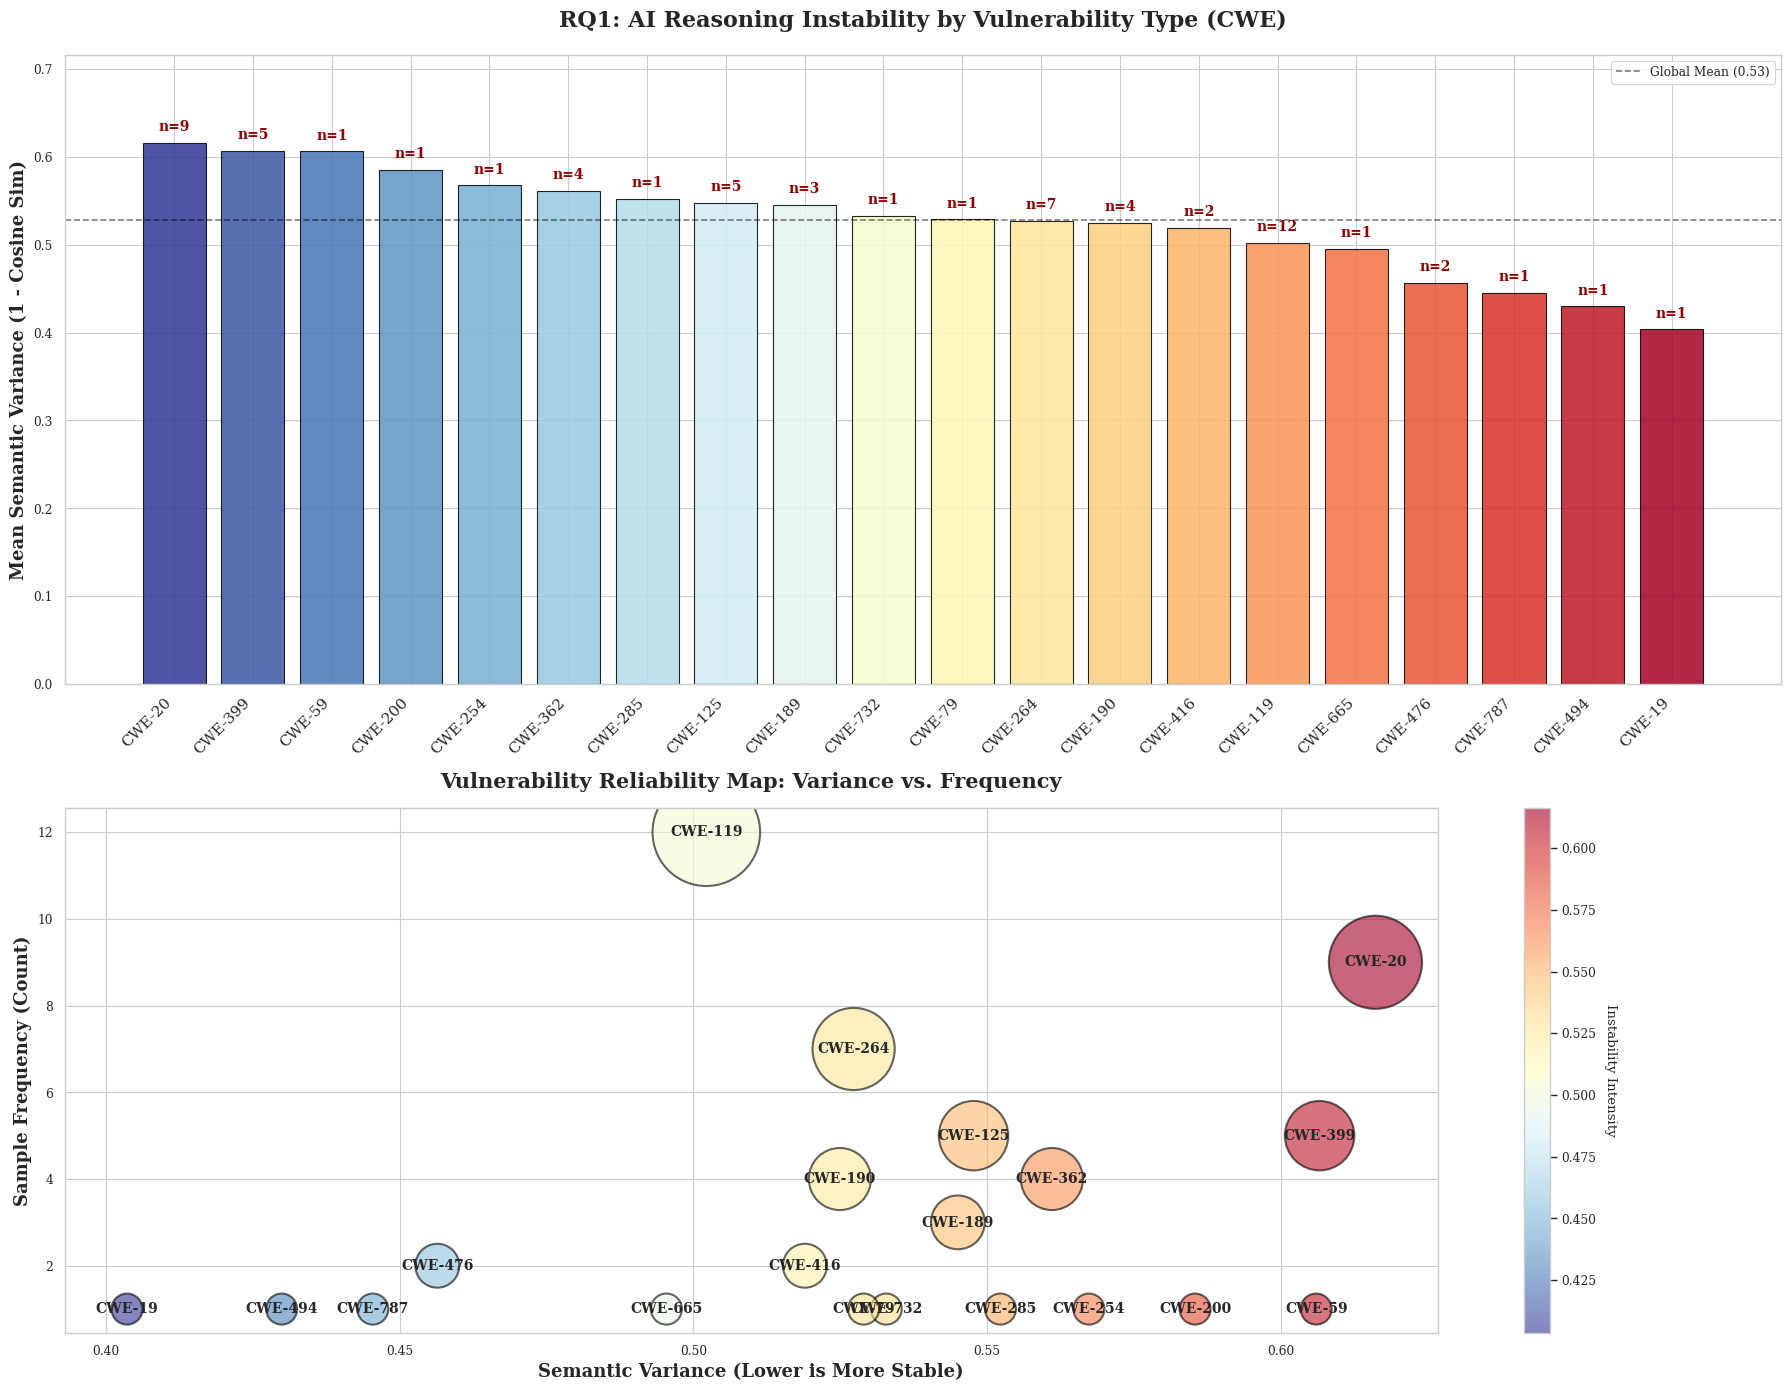


 Strategy
1. Focus on the Red bars (CWE-20, CWE-399): These are 'Name-Dependent' bugs.
2. Focus on Large Bubbles at high variance: These are statistically significant failures.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from Google Drive
results_dir = '/content/drive/MyDrive/Project/results/'
file_path = results_dir + "cwe_sensitivity_stats.csv"

df = pd.read_csv(file_path)

# Sort by mean variance
df_sorted = df.sort_values(by="mean", ascending=False)

print("Data preview:")
display(df)

# Plot 1: Sensitivity Ranking
plt.figure(figsize=(10,7))

plt.barh(df_sorted["cwe"], df_sorted["mean"])

plt.xlabel("Mean Variance of AI Explanation")
plt.ylabel("CWE Type")
plt.title("CWE Sensitivity to Explanation Perturbation")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Plot 2: Sensitivity vs Sample Size
plt.figure(figsize=(10,6))

plt.scatter(
    df["mean"],
    df["count"],
    s=df["count"]*80,
    alpha=0.7
)

for i, txt in enumerate(df["cwe"]):
    plt.annotate(txt, (df["mean"][i], df["count"][i]), fontsize=9)

plt.xlabel("Mean Variance of Explanation")
plt.ylabel("Number of Samples (Count)")
plt.title("CWE Sensitivity vs Sample Size")

plt.tight_layout()
plt.show()


# Plot 3: Mean Variance with Count Overlay
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(df_sorted["cwe"], df_sorted["mean"])
ax1.set_ylabel("Mean Variance")
ax1.set_xlabel("CWE Type")
ax1.set_title("AI Explanation Sensitivity by CWE")

ax1.tick_params(axis='x', rotation=60)

# Secondary axis for count
ax2 = ax1.twinx()
ax2.plot(df_sorted["cwe"], df_sorted["count"], marker='o')
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set academic style
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'serif'

# 1. Load data
results_dir = '/content/drive/MyDrive/Project/results/'
df = pd.read_csv(results_dir + "cwe_sensitivity_stats.csv")
df_sorted = df.sort_values(by="mean", ascending=False)

# Create a professional 2-panel dashboard
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 1])

# Plot A: The "Brittleness" Ranking (Bar + Count Annotation)
ax1 = fig.add_subplot(gs[0])
# Using a color map to highlight severity
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, len(df_sorted)))

bars = ax1.bar(df_sorted["cwe"], df_sorted["mean"], color=colors, edgecolor='black', alpha=0.85)

# Add 'n=X' count labels on top of bars
for bar, count in zip(bars, df_sorted["count"]):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'n={int(count)}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color='darkred')

ax1.set_ylabel("Mean Semantic Variance (1 - Cosine Sim)", fontsize=13, fontweight='bold')
ax1.set_title("RQ1: AI Reasoning Instability by Vulnerability Type (CWE)", fontsize=16, fontweight='bold', pad=20)
ax1.set_ylim(0, df_sorted["mean"].max() + 0.1)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=11)

# Add a horizontal line for the "Global Average"
mean_val = df["mean"].mean()
ax1.axhline(mean_val, color='black', linestyle='--', alpha=0.5, label=f'Global Mean ({mean_val:.2f})')
ax1.legend()

# Plot B: Statistical Significance Bubble Chart
ax2 = fig.add_subplot(gs[1])

# Bubble size based on count, color based on variance
scatter = ax2.scatter(
    df["mean"], 
    df["count"], 
    s=df["count"]*500, # Large bubbles for visibility
    c=df["mean"], 
    cmap='RdYlBu_r', 
    alpha=0.6, 
    edgecolors="black", 
    linewidth=1.5
)

# Annotate each bubble with CWE ID
for i, txt in enumerate(df["cwe"]):
    ax2.annotate(txt, (df["mean"][i], df["count"][i]), 
                 fontsize=10, fontweight='bold', ha='center', va='center')

ax2.set_xlabel("Semantic Variance (Lower is More Stable)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Sample Frequency (Count)", fontsize=13, fontweight='bold')
ax2.set_title("Vulnerability Reliability Map: Variance vs. Frequency", fontsize=15, fontweight='bold', pad=15)

# Add a colorbar for the heat scale
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Instability Intensity', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig(results_dir + "rq1_comprehensive_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n Strategy")
print("1. Focus on the Red bars (CWE-20, CWE-399): These are 'Name-Dependent' bugs.")
print("2. Focus on Large Bubbles at high variance: These are statistically significant failures.")